# 02 · Diagnóstico de calidad

Antes de limpiar hay que saber qué está mal. Este notebook **no corrige nada**:
llama a `calidad.diagnostico.diagnosticar()`, que solo describe completitud
temporal, valores y estructura.

In [1]:
import sys, warnings
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=FutureWarning)

DATASETS = RAIZ / "datasets"
print("raiz     :", RAIZ)
print("datasets :", DATASETS, "->", "existe" if DATASETS.exists() else "FALTA")

raiz     : C:\Users\manue\OneDrive\Documentos\PROYECTOS PORTAFOLIO REAL\SIEM EXPLORER
datasets : C:\Users\manue\OneDrive\Documentos\PROYECTOS PORTAFOLIO REAL\SIEM EXPLORER\datasets -> existe


In [2]:
from ingesta.normalizar import xm_cliente_a_esquema_comun

crudo_xm = pd.read_csv(DATASETS / "xm" / "xm_demareal_sistema.csv", parse_dates=["timestamp"])
xm = xm_cliente_a_esquema_comun(crudo_xm)
print(f"{len(xm):,} filas · {xm.fecha_hora.min()} .. {xm.fecha_hora.max()}")

from calidad.diagnostico import diagnosticar, resumen
informe = diagnosticar(xm)
print(resumen(informe))

49,824 filas · 2021-01-01 00:00:00-05:00 .. 2026-09-07 23:00:00-05:00


DIAGNOSTICO DE CALIDAD
Generado    : 2026-09-11T04:57:58
Forma       : agregada (1.0 filas/hora)
Columnas    : tiempo=fecha_hora  valor=valor_kwh
Filas       : 49,824

--------------------------------------------------------------------------
COMPLETITUD TEMPORAL
--------------------------------------------------------------------------
Rango           : 2021-01-01 00:00:00-05:00 .. 2026-09-07 23:00:00-05:00
Horas           : 49,824 de 49,824 esperadas (100.0%)
Huecos          : ninguno
Timestamps rep. : 0
Dias != 24 h    : ninguno

--------------------------------------------------------------------------
VALORES
--------------------------------------------------------------------------
Descriptivos    : n=49,824  media=9,112,372.5  mediana=9,161,207.6
                  min=1,647,657.9  max=12,644,446.6
Nulos           : en 1 columnas
    version                    49,824  (100.0%)
Ceros/negativos : 0 ceros, 0 negativos
Atipicos IQR    : 48 (0.0963%)  fuera de [5,335,213, 12,874,199]


## Los huecos, uno a uno

Tres horas sueltas y dos semanas seguidas no admiten el mismo tratamiento, así
que el informe los separa por duración.

In [3]:
huecos = informe["completitud"]["huecos"]
print("tramos:", huecos["n_tramos"], "· forma:", huecos["forma"])
print("por clase:", huecos["tramos_por_clase"])
pd.DataFrame(huecos["tramos"]) if huecos["tramos"] else print("Sin huecos: la serie está completa.")

tramos: 0 · forma: sin huecos
por clase: {}
Sin huecos: la serie está completa.


## Por qué el criterio estacional importa más que el global

Un valor alto a las 2 de la tarde es normal; el mismo a las 3 de la madrugada no
lo es. El IQR global no distingue la hora, así que marca picos normales.

In [4]:
iqr = informe["valores"]["outliers_iqr"]
est = informe["valores"]["outliers_estacionales"]
print(f"IQR global : {iqr['n_outliers']:>5} atípicos ({iqr['pct']}%)  "
      f"límites [{iqr['limite_inferior']:,.0f}, {iqr['limite_superior']:,.0f}]")
print(f"Estacional : {est['n_outliers']:>5} atípicos ({est['pct']}%)  "
      f"fiabilidad {est['fiabilidad']}, {est['observaciones_por_grupo_mediana']} obs/grupo")
pd.DataFrame(est["ejemplos"])

IQR global :    48 atípicos (0.0963%)  límites [5,335,213, 12,874,199]
Estacional :   157 atípicos (0.3151%)  fiabilidad alta, 297.0 obs/grupo


,momento,valor,mediana_grupo,z,dia_semana,hora
0,2026-09-06 09:00:00-05:00,2900415.08,7956790.73,-11.40,domingo,9
1,2026-09-06 19:00:00-05:00,1720475.24,9471309.76,-11.25,domingo,19
2,2026-09-06 20:00:00-05:00,1662545.05,9345329.07,-11.22,domingo,20
3,2026-09-06 10:00:00-05:00,3008615.66,8248093.39,-11.21,domingo,10
4,2026-09-06 11:00:00-05:00,3023788.59,8503265.51,-10.84,domingo,11
5,2026-09-06 12:00:00-05:00,2937088.80,8621070.41,-10.65,domingo,12
6,2026-09-06 13:00:00-05:00,2845572.25,8604043.76,-10.41,domingo,13
7,2026-09-06 18:00:00-05:00,1664202.05,9183054.07,-10.36,domingo,18
8,2026-09-07 19:00:00-05:00,2028790.25,10407166.74,-10.35,lunes,19
9,2026-09-06 21:00:00-05:00,1647657.93,9059697.43,-10.28,domingo,21


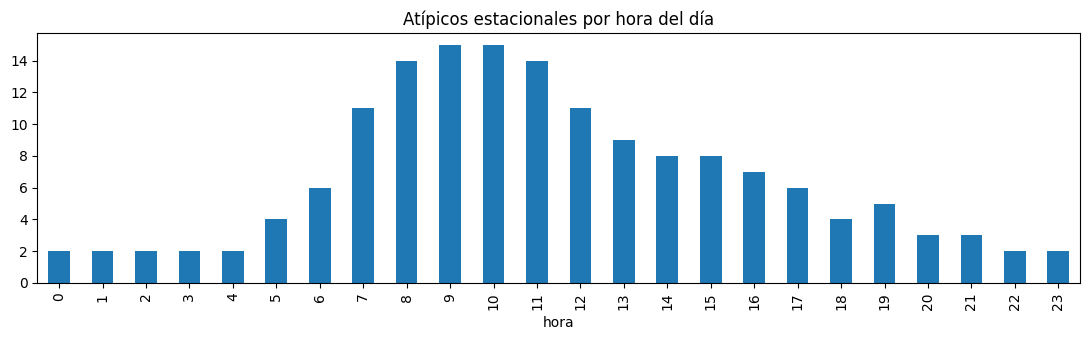

In [5]:
por_hora = pd.Series({int(h): n for h, n in est["por_hora_del_dia"].items()}).sort_index()
if len(por_hora):
    por_hora.plot.bar(figsize=(11, 3.5), title="Atípicos estacionales por hora del día")
    plt.xlabel("hora"); plt.tight_layout(); plt.show()

## Los últimos días publicados

Los dos últimos días publicados suelen llegar con valores parciales aunque
tengan las 24 horas y ningún nulo. Ninguna comprobación de completitud lo ve:
el defecto está en los valores, no en la rejilla de tiempo.

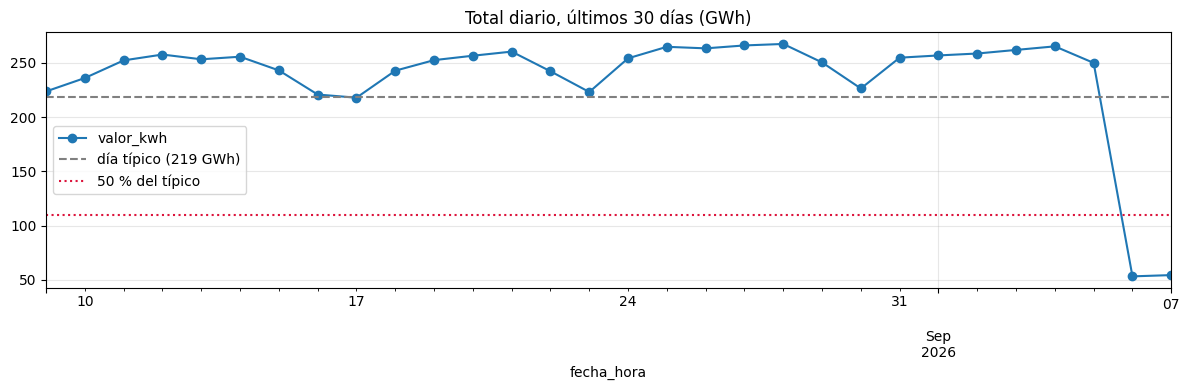

días por debajo del 50 % del típico: 2
fecha_hora
2026-09-06 00:00:00-05:00    53.2
2026-09-07 00:00:00-05:00    54.3
Freq: D


In [6]:
diario = xm.set_index("fecha_hora").valor_kwh.resample("D").sum() / 1e6
tipico = diario.iloc[:-30].median()

ax = diario.tail(30).plot(figsize=(12, 4), marker="o", title="Total diario, últimos 30 días (GWh)")
ax.axhline(tipico, ls="--", c="gray", label=f"día típico ({tipico:.0f} GWh)")
ax.axhline(tipico * .5, ls=":", c="crimson", label="50 % del típico")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

parciales = diario[diario < tipico * .5]
print(f"días por debajo del 50 % del típico: {len(parciales)}")
print(parciales.round(1).to_string())

> **Para el modelado:** el rezago útil no es de 3 días sino de ~5. Conviene
> descartar los últimos 5 días de cualquier partición de entrenamiento o validación.